In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [3]:
df=pd.read_csv('loan_approval_dataset.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1000 non-null   int64 
 1   Salary             1000 non-null   int64 
 2   Credit_Score       1000 non-null   int64 
 3   Loan_Amount        1000 non-null   int64 
 4   Loan_Term          1000 non-null   object
 5   Employment_Status  1000 non-null   object
 6   Residence_Type     1000 non-null   object
 7   Previous_Default   1000 non-null   object
 8   Loan_Approved      1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


In [5]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [6]:
x=df.drop(columns='Loan_Approved')
y=df['Loan_Approved']

In [7]:
obj_cols=x.select_dtypes(include='object').columns
num_cols=x.select_dtypes(include='number').columns

In [8]:
df.corr(numeric_only=True)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<Axes: >

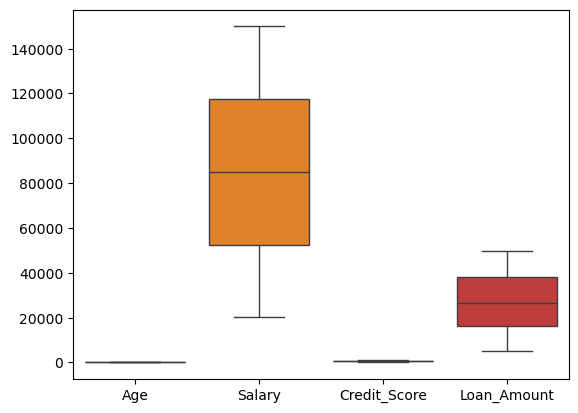

In [10]:
sns.boxplot(df[num_cols])

In [11]:
x[obj_cols].nunique()

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

In [15]:
onehot_col=['Loan_Term','Employment_Status','Residence_Type','Previous_Default']

minmax_col=['Age','Salary','Credit_Score','Loan_Amount']

In [16]:
pre_processing=ColumnTransformer(
    transformers=[
        ('onehotencoder',OneHotEncoder(handle_unknown='ignore',sparse_output=False),onehot_col),
        ('minmaxscaler',MinMaxScaler(),minmax_col)
    ],remainder='passthrough'
)

In [17]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing',pre_processing),
        ('model',LogisticRegression())
    ]
)

In [18]:
grid_search_cv=GridSearchCV(
    estimator=main_pipeline,
    param_grid={
        'model__penalty':['l1','l2'],
        'model__solver':['liblinear','saga'],
        'model__max_iter':[100]
    },verbose=1 # verbose tells Scikit-learn how much information to print while the model is running
)

In [19]:
grid_search_cv.fit(x_train,y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,estimator,Pipeline(step...egression())])
,param_grid,"{'model__max_iter': [100], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear', 'saga']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('onehotencoder', ...), ('minmaxscaler', ...)]"


In [20]:
grid_search_cv.best_estimator_

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('onehotencoder', ...), ('minmaxscaler', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [21]:
grid_search_cv.best_params_

{'model__max_iter': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

* If the labels are three model internally uses soft max

* sag and saga we use this when we have more features in sentence based classification